In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
from plotting_code import apply_style, add_panel_label, create_multi_panel_figure
apply_style()

In [98]:
combined_df = pd.concat([
    pd.read_csv('results/approx_seed_results.csv'),
    pd.read_csv('results/magpie_seed_results.csv'),
    pd.read_csv('results/oliynyk_seed_results.csv'),
], ignore_index=True)

# Compute summary from raw data
summary = combined_df.groupby(['feature_set', 'model']).agg(
    acc_mean=('test_acc', 'mean'),
    acc_std= ('test_acc', 'std'),
    f1_mean= ('test_f1',  'mean'),
    f1_std=  ('test_f1',  'std'),
).round(4)

print(summary)

                   acc_mean  acc_std  f1_mean  f1_std
feature_set model                                    
approx      etc      0.8627   0.0042   0.8643  0.0038
            lr       0.6491   0.0000   0.6416  0.0000
            rfc      0.8548   0.0053   0.8562  0.0049
            svc      0.6623   0.0000   0.6665  0.0000
magpie      etc      0.8579   0.0069   0.8589  0.0068
            lr       0.6623   0.0000   0.6562  0.0000
            rfc      0.8474   0.0068   0.8490  0.0067
            svc      0.6974   0.0000   0.6946  0.0000
oliynyk     etc      0.8592   0.0053   0.8608  0.0049
            lr       0.6798   0.0000   0.6761  0.0000
            rfc      0.8566   0.0069   0.8588  0.0063
            svc      0.7500   0.0000   0.7518  0.0000


In [99]:
feature_order  = ['approx', 'magpie', 'oliynyk']
model_order    = ['etc', 'rfc', 'lr', 'svc']

model_labels = {
    'etc': 'Extra Trees',
    'rfc': 'Random Forest',
    'lr':  'Logistic Regression',
    'svc': 'SVC',
}

feature_labels = {
    'approx': 'Approx',
    'magpie': 'MAGPIE',
    'oliynyk': 'Oliynyk',
}

feature_colors = {
    'approx':  '#57106e',
    'magpie':  '#e55c30',
    'oliynyk': '#fbbe23',
}

custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])

feature_hatches = {
    'approx':  '//',
    'magpie':  '..',
    'oliynyk': 'xx',
}

In [100]:
def plot_bar(ax, summary):
    x = np.arange(len(model_order))
    width = 0.25

    for i, feat in enumerate(feature_order):
        data = summary.xs(feat, level='feature_set').reindex(model_order)

        ax.bar(
            x + (i - 1) * width,
            data['f1_mean'],
            width=width,
            yerr=data['f1_std'],
            color=feature_colors[feat],
            hatch=feature_hatches[feat],
            edgecolor='white',
            linewidth=0.5,
            capsize=4,
            label=feature_labels[feat],
            zorder=2
        )

    ax.set_xticks(x)
    ax.set_xticklabels([model_labels[m] for m in model_order])
    ax.set_ylabel('F1 score')
    ax.set_ylim(0, 1.0)

    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

    ax.legend(
        title='Feature set',
        frameon=False,
        loc='upper right',
        bbox_to_anchor=(0.9, 1.0)
    )

In [101]:
def plot_heatmap(ax, summary):
    pivot = summary['f1_mean'].unstack('feature_set').reindex(
        index=model_order, columns=feature_order
    )

    pivot.index = [model_labels[m] for m in model_order]

    sns.heatmap(pivot, annot=True, fmt='.3f', vmin=0.5, vmax=1,
        cmap=custom_cmap, linewidths=0.5, linecolor='white',
        cbar_kws={'label': 'Mean F1 score'},
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('')

    # Move labels to top
    ax.xaxis.tick_top()
    ax.set_xticklabels(
        [feature_labels[f] for f in feature_order],
    )
    ax.set_yticklabels(pivot.index, rotation=0)

    # Hide tick marks (NOT ticks themselves)
    ax.tick_params(axis='both', which='both', length=0)
    
    cbar = ax.collections[0].colorbar
    cbar.outline.set_visible(True)
    cbar.outline.set_linewidth(1.5)

In [108]:
def make_bar_figure(summary):
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_bar(ax, summary)
    plt.tight_layout()
    return fig


def make_heatmap_figure(summary):
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_heatmap(ax, summary)
    plt.tight_layout()
    return fig


def make_combined_figure(summary):
    fig, axes = create_multi_panel_figure(
        nrows=1,
        ncols=2,
        figsize=(16, 5),
        width_ratios=[1.4, 1],
        wspace=0.35
    )

    plot_bar(axes[0], summary)
    plot_heatmap(axes[1], summary)

    add_panel_label(axes[0], '(a)')
    add_panel_label(axes[1], '(b)')

    return fig

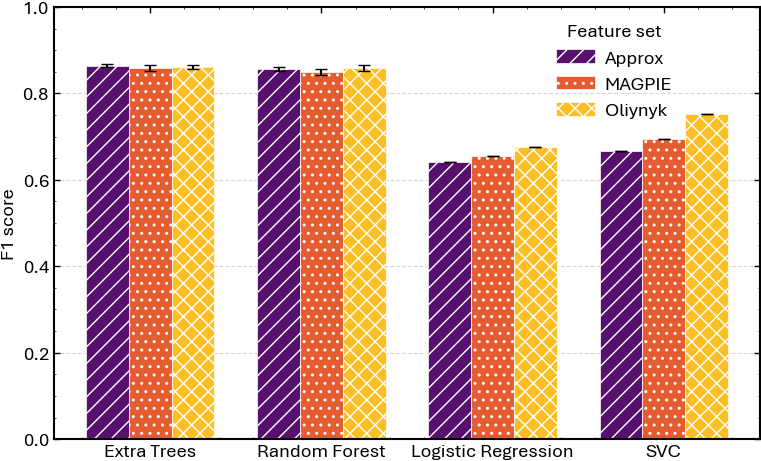

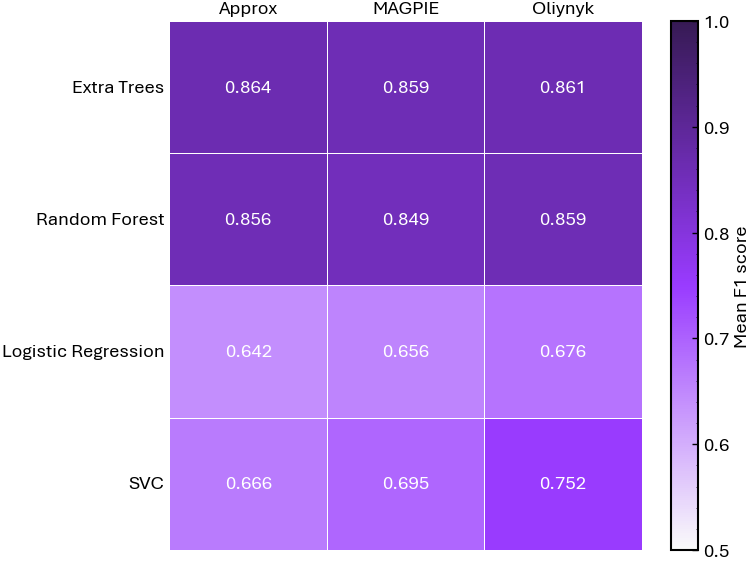

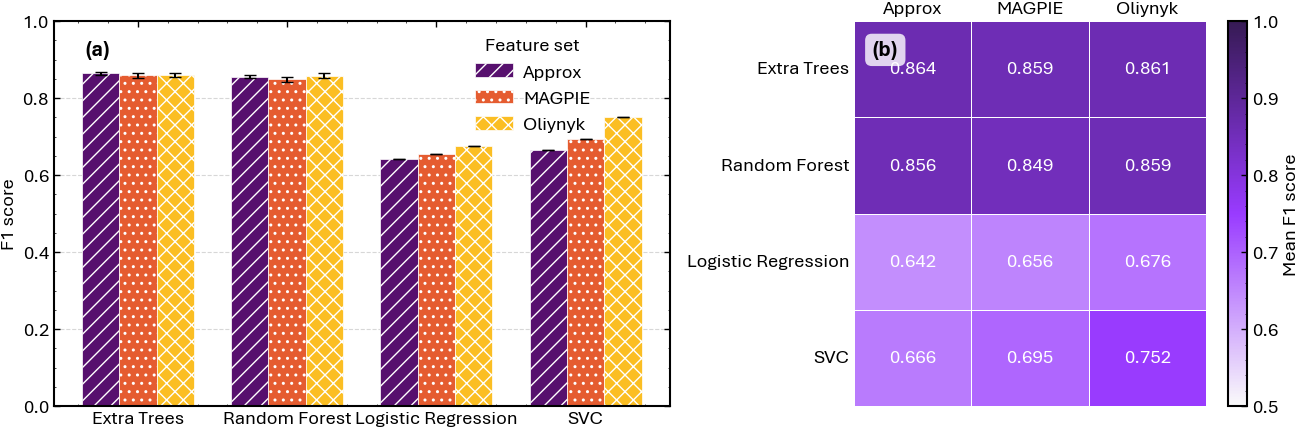

In [109]:
fig = make_bar_figure(summary)
plt.show()

fig = make_heatmap_figure(summary)
fig.savefig('outputs/F1_score_heatmap.png')
plt.show()

fig = make_combined_figure(summary)
plt.show()